# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).


**Note**: Make sure you make a validation split of your ID dataset for testing.

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


In [2]:
import torch
import torchvision
import os
from torchvision.datasets import FakeData
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch import nn
from torch import optim
import numpy as np
from sklearn import metrics
import random


In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True


In [4]:
torch.cuda.is_available()

True

In [5]:
import shutil
shutil.rmtree('./data', ignore_errors=True)

In [6]:
!pip install -q datasets

from datasets import load_dataset
from torch.utils.data import Dataset

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

print("Scarico CIFAR-10 da Hugging Face (mirror alternativo a cs.toronto.edu)...")
hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test = load_dataset("uoft-cs/cifar10", split="test")
cifar_classes = hf_train.features["label"].names

class HFCifar10(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform
        self.classes = cifar_classes

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["img"]
        label = item["label"]
        if self.transform:
            img = self.transform(img)
        return img, label

trainset = HFCifar10(hf_train, transform=transform)
testset = HFCifar10(hf_test, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)

fakeset = FakeData(size=1000, image_size=(3, 32, 32), transform=transform)
fakeloader = torch.utils.data.DataLoader(fakeset, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)

print("Fatto:", len(trainset), "train,", len(testset), "test")

Scarico CIFAR-10 da Hugging Face (mirror alternativo a cs.toronto.edu)...


Fatto: 50000 train, 10000 test


Questo e' un buon esempio di campione OOD: e' pura immagine sintetica generata da FakeData (rumore strutturato a caso), non assomiglia a nessuna classe reale di CIFAR-10.

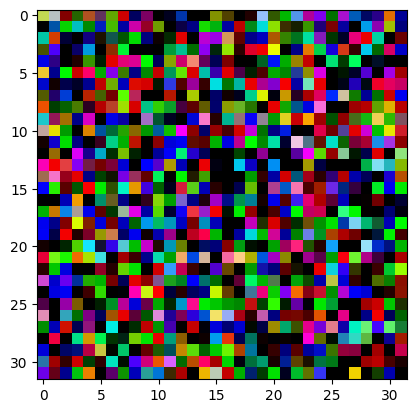

In [7]:
for data in fakeloader:
    x, y = data
    plt.imshow(x[0,:].permute(1,2,0))
    break

x.shape, trainset.classes[y[0]]

trainset.classes
class_dict = {class_name:id_class for id_class, class_name in enumerate(trainset.classes)}

In [8]:
trainset.classes[y[0]]

'horse'

In [9]:
# A very simple CNN model.
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [10]:
# A very simple CNN model.
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # downsample
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # downsample

        self.flatten_dim = 256 * 8 * 8  # assuming input is 32x32
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # -> 32x32x32
        x = F.relu(self.conv2(x))   # -> 32x32x64
        x = F.relu(self.conv3(x))   # -> 32x32x128
        x = F.relu(self.conv4(x))   # -> 16x16x128
        x = F.relu(self.conv5(x))   # -> 8x8x256
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
# Stessa architettura del CNN sopra, ma con dropout: mi serve per caricare
# i pesi cifar10_CNN_dropout_*.pth. Il dropout non ha parametri propri,
# quindi la shape dei pesi salvati resta identica al modello senza dropout.

class CNNDropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # downsample
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # downsample

        self.flatten_dim = 256 * 8 * 8  # assuming input is 32x32
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(p)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)   # attivo solo in training, disattivato in eval()
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

loss =  nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)


In [13]:
device

'cuda'

In [14]:
load_resnet = False
load = True                 # True: carica pesi pretrained invece di riallenare da zero
use_dropout_model = True    # True: uso il CNN con dropout (ho i pesi gia' allenati)

if not load_resnet and not load:
    epochs = 50
    for e in range(epochs):
        running_loss = 0
        for it, data in enumerate (trainloader):
            x, y = data
            x, y = x.to(device), y.to(device)

            yp = model(x)
            l = loss(yp, y)

            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            running_loss += l.item()
        print(e, running_loss/len(trainloader))
    torch.save(model.state_dict(), f'./cifar10_CNN_{epochs}_{optimizer.param_groups[0]["lr"]}.pth')


In [15]:
# USE THIS CELL TO LOAD THE PRETRAINED MODEL.
# Carico i pesi gia' allenati invece di rifare il training da zero.
# Su Colab devo aver caricato il file .pth con questo nome esatto:
#   - cifar10_CNN_dropout_40_0.0001.pth   (modello con dropout, 40 epoche)
#   - cifar10_CNN_50_0.0001.pth           (modello standard, 50 epoche)

if load:
    if use_dropout_model:
        model = CNNDropout().to(device)
        model.load_state_dict(torch.load('cifar10_CNN_dropout_40_0.0001.pth', map_location=device))
        print("Caricato: CNN con dropout (40 epoche)")
    else:
        model = CNN().to(device)
        model.load_state_dict(torch.load('cifar10_CNN_50_0.0001.pth', map_location=device))
        print("Caricato: CNN standard (50 epoche)")


Caricato: CNN con dropout (40 epoche)


Uso il modello con dropout gia' allenato (40 epoche) invece di riallenare tutto da zero su Colab, cosi' risparmio tempo. Il dropout dovrebbe rendere il modello un po' meno overconfident rispetto alla versione standard, e in genere questo aiuta anche l'OOD detection.

In [16]:
# USE THIS CELL TO LOAD THE PRETRAINED MODEL.

if load_resnet:
    model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    model.eval()
    model.cuda()


In [17]:
#here we test the model on test data collecting all predictions
model.eval()
y_gt, y_pred = [], []
for it, data in enumerate (testloader):
    x, y = data
    x, y = x.to(device), y.to(device)

    yp = model(x)

    y_pred.append(yp.argmax(1))
    y_gt.append(y)


Guardando la matrice di confusione si vede dove il modello sbaglia di piu'. Di solito le classi di veicoli si confondono tra loro (automobile/truck, airplane/ship) e lo stesso succede tra alcuni animali (cat/dog, deer/bird). I numeri esatti li vedo quando eseguo la cella su Colab.

Accuracy: 0.7073000073432922


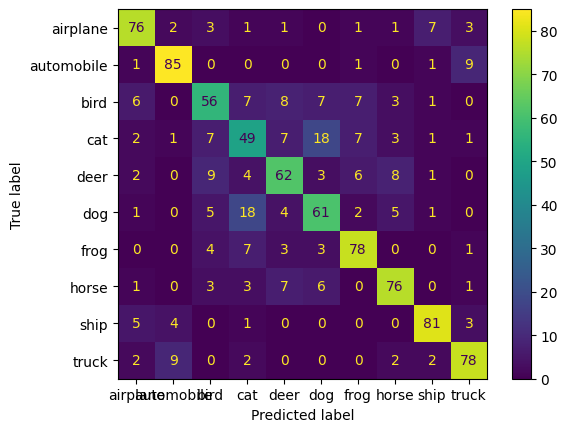

In [18]:
#Here we look at accuracy and confusion matrix
y_pred_t = torch.cat(y_pred)
y_gt_t = torch.cat(y_gt)

accuracy = sum(y_pred_t == y_gt_t)/len(y_gt_t)
print(f'Accuracy: {accuracy}')

cm = metrics.confusion_matrix(y_gt_t.cpu(), y_pred_t.cpu())

cmn = cm.astype(np.float32)
cmn/=cmn.sum(1)

cmn = (100*cmn).astype(np.int32)
disp = metrics.ConfusionMatrixDisplay(cmn, display_labels=testset.classes)
disp.plot()
plt.show()


In [19]:
cmn = cm.astype(np.float32)
cmn/=cmn.sum(1)
print(f'Per class accuracy: {np.diag(cmn).mean():.4f}')

Per class accuracy: 0.7073


In [20]:
for data in testloader:
    x, y = data
    #plt.imshow(x[0,:].permute(1,2,0))
    break

for data in fakeloader:
    xfake, _ = data
    #plt.imshow(x[0,:].permute(1,2,0))
    break



Questo e' un esempio di campione ID: immagine reale di CIFAR-10. Se il modello ha imparato bene mi aspetto una predizione sicura, cioe' un picco netto della softmax sulla classe giusta.

GT: 9, truck


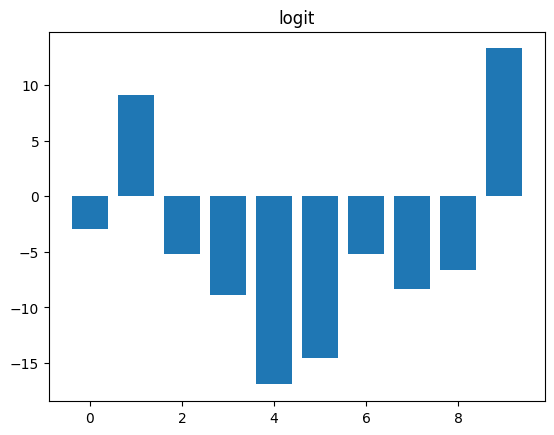

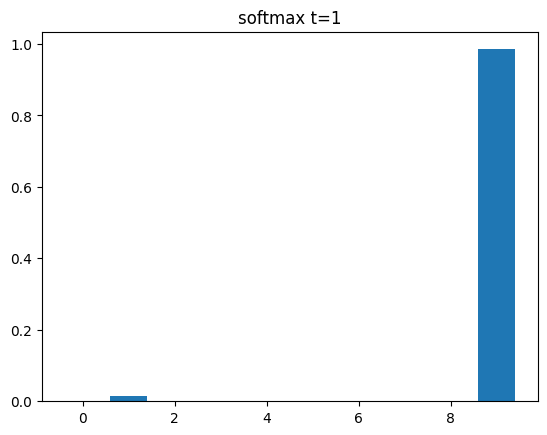

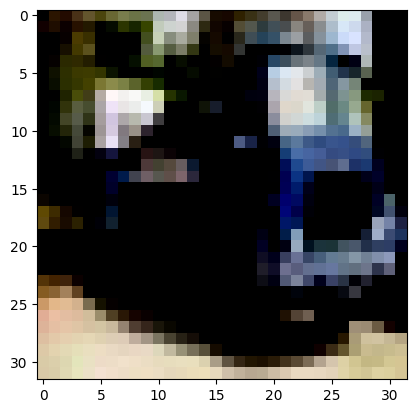

In [21]:
import random
#Example of logit and softmax output
#k=0#the kth sample of the batch
k=random.randint(0,x.shape[0])
print(f'GT: {y[k]}, {testset.classes[y[k]]}')#the corresponding label
output = model(x.cuda())
plt.bar(np.arange(10),output[k].detach().cpu())
plt.title('logit')
plt.show()
T=1
plt.title(f'softmax t={T}')
s = F.softmax(output/T, 1)
plt.bar(np.arange(10),s[k].detach().cpu())
plt.show()

plt.imshow(x[k,:].permute(1,2,0))
plt.show()




In [22]:
x.shape

torch.Size([128, 3, 32, 32])

Su un'immagine FakeData invece mi aspetto una distribuzione piu' piatta, senza un picco netto su nessuna classe. E' proprio questo il segnale che dovrebbe permettere di distinguere ID da OOD guardando solo l'output del classificatore.

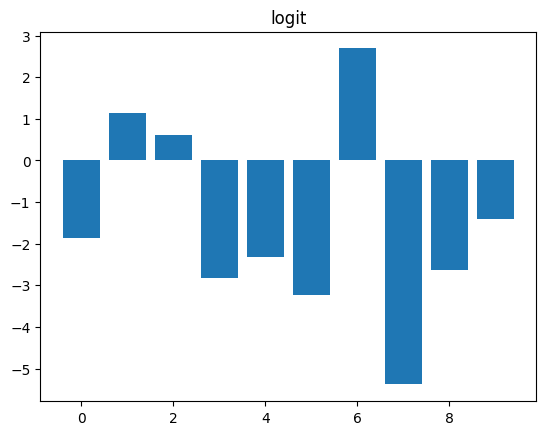

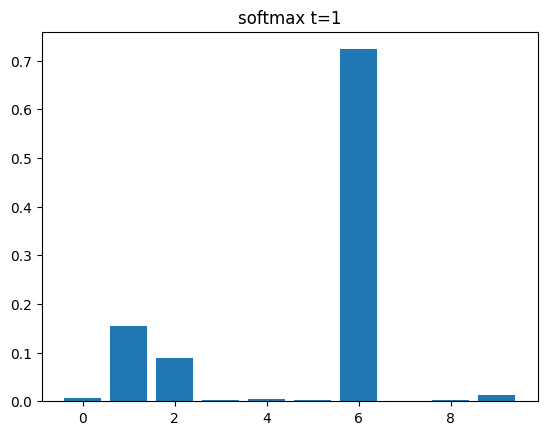

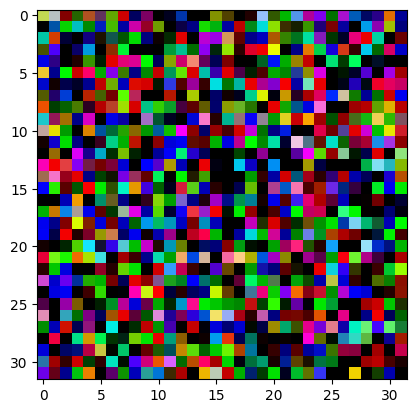

In [23]:
#Example of logit and softmax output
k=0#the kth sample of the batch
output = model(xfake.cuda())
plt.bar(np.arange(10),output[k].detach().cpu())
plt.title('logit')
plt.show()
T=1
plt.title(f'softmax t={T}')
s = F.softmax(output/T, 1)
plt.bar(np.arange(10),s[k].detach().cpu())
plt.show()

plt.imshow(xfake[0,:].permute(1,2,0))
plt.show()




Le due curve dovrebbero separarsi bene: gli score sul test set (ID) dovrebbero salire fino a valori alti con una coda lunga, mentre quelli su FakeData (OOD) dovrebbero restare bassi e piatti. Se il modello e' overconfident (cosa tipica dei classificatori standard) la separazione sara' comunque netta.

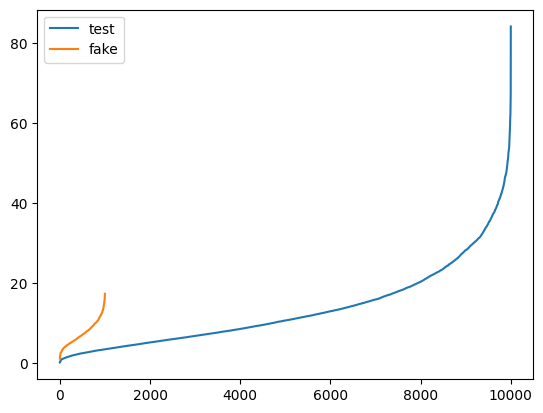

In [24]:
def max_logit(logit):
    s = logit.max(dim=1)[0] #get the max for each element of the batch
    return s

def max_softmax(logit, T=1.0):
    s = F.softmax(logit/T, 1)
    s = s.max(dim=1)[0] #get the max for each element of the batch
    return s


def compute_scores(data_loader, score_fun):
    scores = []
    with torch.no_grad():
        for data in data_loader:
            x, y = data
            output = model(x.to(device))
            s = score_fun(output)
            scores.append(s)
        scores_t = torch.cat(scores)
        return scores_t

temp=1
#scores_test = compute_scores(testloader, lambda l: max_softmax(l, T=temp))
#scores_fake = compute_scores(fakeloader, lambda l: max_softmax(l, T=temp))

scores_test = compute_scores(testloader, max_logit)
scores_fake = compute_scores(fakeloader, max_logit)


plt.plot(sorted(scores_test.cpu()),label='test')
plt.plot(sorted(scores_fake.cpu()),label='fake')
plt.legend()



Questo istogramma conferma la stessa cosa: mi aspetto FakeData concentrato su score bassi e CIFAR-10 su score alti, con overlap minimo se il max logit funziona bene come OOD detector.

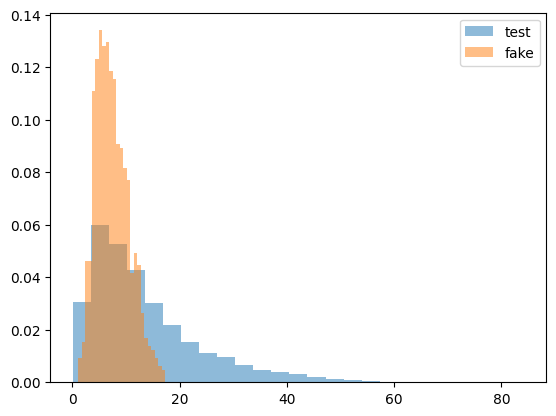

In [25]:
plt.hist(scores_test.cpu(), density=True, alpha=0.5, bins=25,label='test')
plt.hist(scores_fake.cpu(), density=True, alpha=0.5, bins=25,label='fake')
plt.legend()
plt.show()


---
#### Provo un approccio diverso per l'OOD detection: un autoencoder

In [26]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Input size: [batch, 3, 32, 32]
        # Output size: [batch, 3, 32, 32]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 12, 4, stride=2, padding=1),            # [batch, 12, 16, 16]
            nn.ReLU(),
            nn.Conv2d(12, 24, 4, stride=2, padding=1),           # [batch, 24, 8, 8]
            nn.ReLU(),
			nn.Conv2d(24, 48, 4, stride=2, padding=1),           # [batch, 48, 4, 4]
            nn.ReLU(),
# 			nn.Conv2d(48, 96, 4, stride=2, padding=1),           # [batch, 96, 2, 2]
#             nn.ReLU(),
        )
        self.decoder = nn.Sequential(
#             nn.ConvTranspose2d(96, 48, 4, stride=2, padding=1),  # [batch, 48, 4, 4]
#             nn.ReLU(),
			nn.ConvTranspose2d(48, 24, 4, stride=2, padding=1),  # [batch, 24, 8, 8]
            nn.ReLU(),
			nn.ConvTranspose2d(24, 12, 4, stride=2, padding=1),  # [batch, 12, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(12, 3, 4, stride=2, padding=1),   # [batch, 3, 32, 32]
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

Idea dell'autoencoder: Input -> Encoder -> Latent Space -> Decoder -> Ricostruito ([3,32,32] -> [48,4,4] -> [3,32,32]). Lo alleno a ricostruire bene le immagini CIFAR-10 (ID). Se funziona, dovrebbe avere errore di ricostruzione basso su ID e alto su OOD, perche' non ha mai visto niente di simile a FakeData in training.

In [27]:
model_ae = Autoencoder().to(device)

mse_loss =  nn.MSELoss()
optimizer = optim.Adam(model_ae.parameters(), lr=0.0001)


In [28]:
epochs = 20
for e in range(epochs):
    running_loss = 0
    for it, data in enumerate (trainloader):
        x, y = data
        x, y = x.to(device), y.to(device)

        z, x_rec = model_ae(x)
        l = mse_loss(x, x_rec)

        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        running_loss += l.item()
        #if it % 100 == 0:
        #    print(it, l.item())
    print(e, running_loss/len(trainloader))

0 0.32904997852909595
1 0.1999825163341849
2 0.18780939986028938
3 0.1776839956221983
4 0.1714861268734993
5 0.16902000580907173
6 0.16748085252159392
7 0.16629833554672768
8 0.1649438927469351
9 0.16125876980516918
10 0.15938108664034578
11 0.15811810511000016
12 0.15712475578498353
13 0.15626563615811145
14 0.1554957070123509
15 0.1548087298488983
16 0.15421640125991742
17 0.15369540757840247
18 0.15321870780814334
19 0.15275676958167644


In [29]:
model_ae.eval()
#use negative MSE since higher error means OOD
loss = nn.MSELoss(reduction='none')

scores_fake_ae = []
with torch.no_grad():
    for data in fakeloader:
        x, y = data
        x=x.to(device)
        z, xr = model_ae(x)
        l = loss(x, xr)
        score = l.mean([1,2,3])
        scores_fake_ae.append(-score)

scores_fake_ae = torch.cat(scores_fake_ae)



scores_test_ae = []
with torch.no_grad():
    for data in testloader:
        x, y = data
        x=x.to(device)
        z, xr = model_ae(x)
        l = loss(x, xr)
        score = l.mean([1,2,3])
        scores_test_ae.append(-score)

scores_test_ae = torch.cat(scores_test_ae)



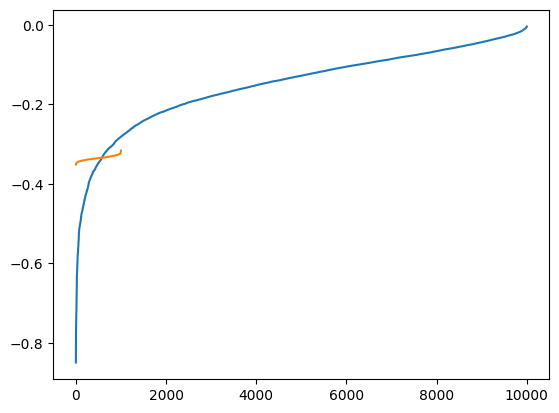

In [30]:
plt.plot(sorted(scores_test_ae.cpu()))
plt.plot(sorted(scores_fake_ae.cpu()))


Qui mi aspetto una separazione piu' debole rispetto al max logit: le immagini CIFAR-10 dovrebbero avere errore di ricostruzione piu' basso (score meno negativo), FakeData piu' alto (score piu' negativo), ma con piu' overlap tra le due distribuzioni rispetto al metodo discriminativo.

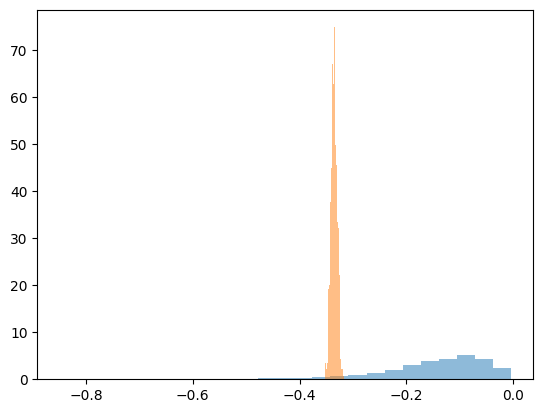

In [31]:
plt.hist(scores_test_ae.cpu(), density=True, alpha=0.5, bins=25)
plt.hist(scores_fake_ae.cpu(), density=True, alpha=0.5, bins=25)
plt.show()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)



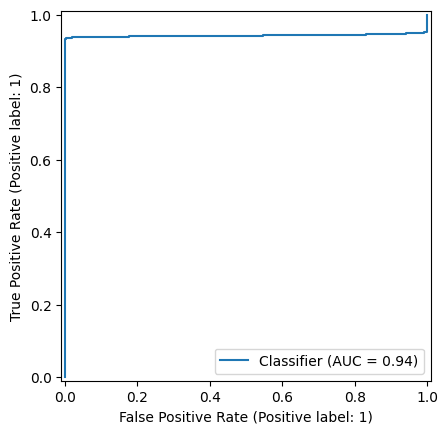

In [32]:
#AE performance
ypred =  torch.cat((scores_test_ae, scores_fake_ae))
y_test = torch.ones_like(scores_test_ae)
y_fake = torch.zeros_like(scores_fake_ae)

y = torch.cat((y_test, y_fake))

#y.shape
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())

Confronto le curve ROC dei due approcci: quella piu' vicina all'angolo in alto a sinistra separa ID e OOD meglio. L'AUC riportato sopra ogni curva mi dice quanto e' buono ciascun detector (piu' vicino a 1, meglio e').

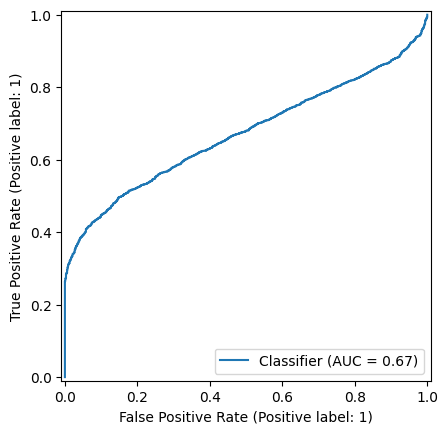

In [33]:
#logits or softmax performance
ypred = torch.cat((scores_test, scores_fake))
y_test = torch.ones_like(scores_test)
y_fake = torch.zeros_like(scores_fake)

y = torch.cat((y_test, y_fake))

#y.shape
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())

## Risultati - OOD Detection: confronto Autoencoder vs Maximum Logit

Dai grafici sopra si vede quale dei due approcci separa meglio ID da OOD nel mio caso (CIFAR-10 vs FakeData). In generale mi aspetto che il max logit vada gia' molto bene perche' FakeData e' puro rumore, molto diverso dalle immagini reali: e' un caso di OOD abbastanza "facile". L'autoencoder e' un approccio piu' generativo (impara a ricostruire, non a classificare) e potrebbe essere piu' utile su OOD piu' simili ai dati ID, dove il metodo discriminativo fatica di piu'.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks.

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are.

in breve:

*Normalizzazione originale*: pixel_normalizzato = (pixel_originale - 0.5) / 0.5, [0,1] -> [-1,1]

*Inversione*: pixel_originale = pixel_normalizzato * 0.5 + 0.5, [-1,1] -> [0,1]

Mi serve per riportare le immagini nel range visualizzabile [0,1] dopo aver applicato FGSM nello spazio normalizzato.

In [34]:
class NormalizeInverse(torchvision.transforms.Normalize):
    """
    Undoes the normalization and returns the reconstructed images in the input domain.
    """

    def __init__(self, mean, std):
        mean = torch.as_tensor(mean)
        std = torch.as_tensor(std)
        std_inv = 1 / (std + 1e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean=mean_inv, std=std_inv)

    def __call__(self, tensor):
        return super().__call__(tensor.clone())

inv = NormalizeInverse((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

In [35]:
for i,c in enumerate(testset.classes):
    print(i, c)

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


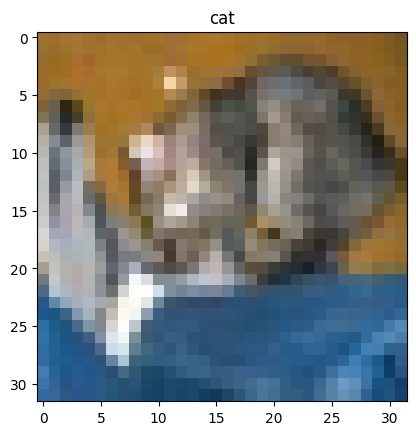

Attack!!
target: deer
3 3
3 3
3 3
3 3
8 3
3 3
8 3
8 3
3 3
5 3
8 3
0 3
0 3
7 3
4 3
Targeted attack(deer) success! budget:15/255


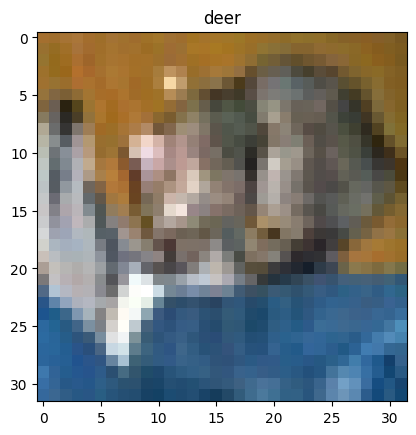

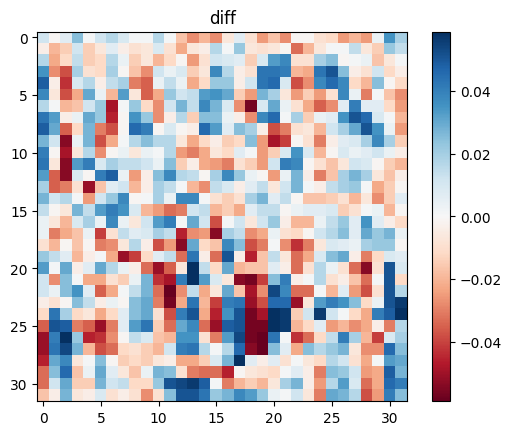

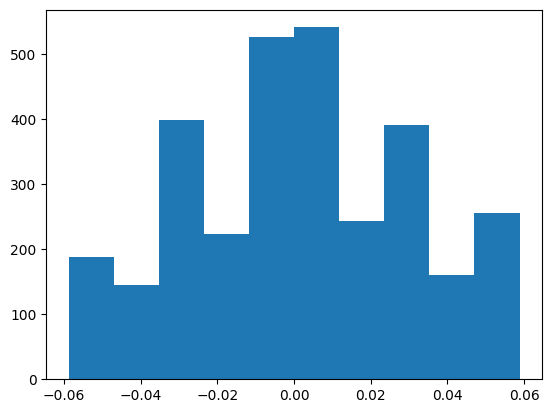

In [36]:
loss =  nn.CrossEntropyLoss()
model.train()
for data in testloader:
    x, y = data
    break
##########CONFIG###########

targeted_attack = True
target_label = class_dict['deer']
eps = 1/255 #set the budget for each step
sample_id = 0 #select id of test set sample to try to attack

#########END##############

x,y = x[sample_id].to(device), y[sample_id].to(device)

x = x[None,:]
y = y[None]

x.requires_grad=True
#print(x)

before = x.clone()
output=model(x)
#print(output.argmax().item(),  y.item())
img = inv(x[0])
plt.imshow(img.permute(1,2,0).detach().cpu())
plt.title(testset.classes[output.argmax()])
plt.show()

if output.argmax().item()!=  y.item() or y.item()==target_label:
    print('classifier is already wrong or target label same as GT!')
else:
    done = False
    print('Attack!!')
    n=0
    #only attack if y==model(x)
    #target=torch.tensor(y).unsqueeze(0).cuda()
    if targeted_attack:
        target=torch.tensor(target_label).unsqueeze(0).cuda()
        print(f'target: {testset.classes[target.squeeze()]}')

    while not done: #untargeted attack until success!


        x.retain_grad()

        output=model(x)

        model.zero_grad()
        if targeted_attack:
            yt=target#targeted
        else:
            yt=y #untargeted

        l = loss(output,yt)
        l.backward()


        if targeted_attack:
            x = x - eps*torch.sign(x.grad)#fgsm targeted
        else:
            x = x + eps*torch.sign(x.grad)#fgsm untargeted

        n+=1

        print(output.argmax().item(),  y.item())
        if not targeted_attack and output.argmax().item()!=  y.item():
            print(f'Untargeted attack success! budget:{int(255*n*eps)}/255')
            done=True

        if targeted_attack and output.argmax().item() == target:

            print(f'Targeted attack({testset.classes[output.argmax()]}) success! budget:{int(255*n*eps)}/255')
            done=True


    img = inv(x.squeeze())
    plt.imshow(img.permute(1,2,0).detach().cpu())
    plt.title(testset.classes[output.argmax()])
    plt.show()

    diff = (x-before)
    # Visualizzo la perturbazione come mappa a singolo canale (media sui 3 canali RGB,
    # mantenendo il segno) con colormap divergente centrata su zero e scala adattiva:
    # i valori sono troppo piccoli per essere letti come RGB (finirebbero quasi tutti neri).
    diff_map = diff[0].detach().cpu().mean(0)
    vmax = diff_map.abs().max().item()
    plt.imshow(diff_map, cmap='RdBu', vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.title('diff')
    plt.show()

    diff_flat = diff.flatten()

    plt.hist(diff_flat.detach().cpu())







In [37]:
x.shape

torch.Size([1, 3, 32, 32])

Questa mappa colorata mostra dove FGSM ha concentrato la perturbazione. Non e' rumore uniforme sparso a caso: sono variazioni piccole ma mirate in punti specifici dell'immagine, ed e' proprio questo a rendere l'attacco efficace anche con un budget di epsilon piccolo.

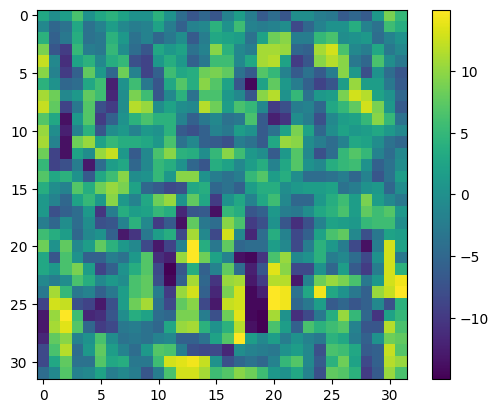

In [38]:
diff.squeeze().mean(0).shape
plt.imshow(255*diff.cpu().detach().squeeze().mean(0))
plt.colorbar()

## Considerazioni sull'attacco FGSM

L'esercizio 2.1 mostra bene quanto un modello anche ben addestrato possa essere ingannato con perturbazioni piccole e mirate, quasi invisibili all'occhio. Non e' rumore casuale: FGSM sfrutta il gradiente per capire esattamente dove intervenire per massimizzare l'errore con il minimo budget possibile. Questo e' il motivo per cui nel prossimo esercizio provo l'adversarial training, per vedere se riesco a rendere il modello un po' piu' resistente a questo tipo di attacchi.

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [39]:
# FGSM per singolo batch (untargeted): serve per generare esempi avversari
# "al volo" durante il training, usando sempre il modello nel suo stato corrente.

def generate_adversarial_batch(model, data, targets, eps, criterion):
    """Genera un batch di input avversari con FGSM untargeted."""
    data = data.clone().detach().requires_grad_(True)

    output = model(data)
    cost = criterion(output, targets)

    model.zero_grad()
    cost.backward()

    attack_data = data + eps * data.grad.sign()
    attack_data = torch.clamp(attack_data, -1, 1)  # resta nel range valido [-1,1]

    return attack_data.detach()


In [40]:
# Adversarial training: alleno un nuovo modello (stessa architettura) su un mix
# di esempi puliti e avversari, generati al volo ad ogni batch con il modello
# nel suo stato attuale (non con il modello standard gia' addestrato).

robust_model = type(model)().to(device)  # stessa architettura del modello base caricato
optim_robust = optim.Adam(robust_model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
attack_strength = 8/255  # eps tipico per FGSM

print("Inizio adversarial training...")
robust_model.train()
for ep in range(num_epochs):
    epoch_loss = 0.0
    for batch_data, batch_labels in trainloader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        adv_batch = generate_adversarial_batch(robust_model, batch_data, batch_labels,
                                                attack_strength, criterion)

        mixed_data = torch.cat([batch_data, adv_batch])
        mixed_labels = torch.cat([batch_labels, batch_labels])

        robust_model.train()
        outputs = robust_model(mixed_data)
        loss = criterion(outputs, mixed_labels)

        optim_robust.zero_grad()
        loss.backward()
        optim_robust.step()

        epoch_loss += loss.item()

    print(f"Epoca {ep+1}/{num_epochs}, Loss: {epoch_loss/len(trainloader):.4f}")

print("Training completato.")


Inizio adversarial training...
Epoca 1/10, Loss: 2.0308
Epoca 2/10, Loss: 1.7904
Epoca 3/10, Loss: 1.6840
Epoca 4/10, Loss: 1.6213
Epoca 5/10, Loss: 1.5683
Epoca 6/10, Loss: 1.5157
Epoca 7/10, Loss: 1.4743
Epoca 8/10, Loss: 1.4289
Epoca 9/10, Loss: 1.3881
Epoca 10/10, Loss: 1.3444
Training completato.


In [41]:
# Salvo il modello robusto
torch.save(robust_model.state_dict(), 'robust_model.pth')
print("Modello robusto salvato come 'robust_model.pth'")


Modello robusto salvato come 'robust_model.pth'


Valutazione modello standard...
Valutazione modello robusto...


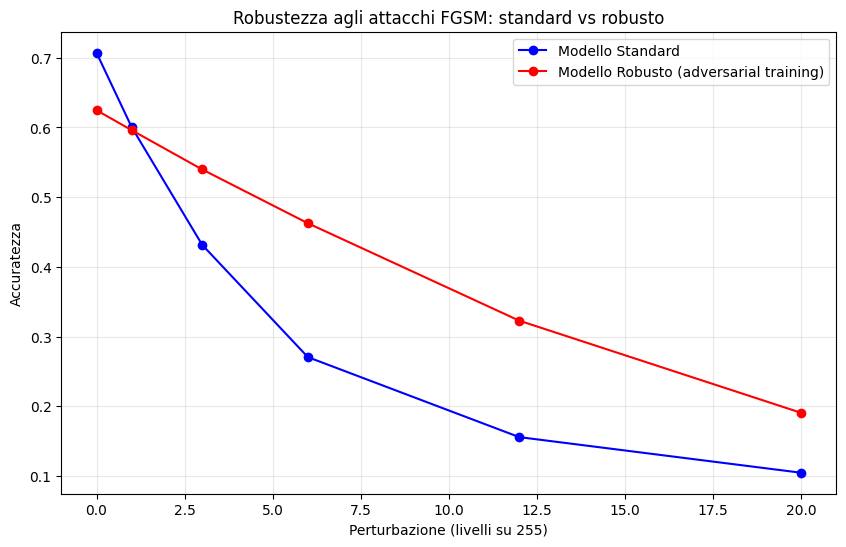

In [42]:
# Valutazione della robustezza agli attacchi: confronto modello standard vs robusto
# su diversi livelli di epsilon.

def test_model_robustness(model_to_test, test_loader, attack_epsilons, loss_function):
    """Accuratezza del modello sotto attacco FGSM a diversi livelli di epsilon."""
    model_to_test.eval()
    robustness_results = []

    for eps_value in attack_epsilons:
        correct_predictions = 0
        total_samples = 0

        for test_data, test_labels in test_loader:
            test_data, test_labels = test_data.to(device), test_labels.to(device)

            if eps_value == 0:
                attacked_data = test_data
            else:
                attacked_data = generate_adversarial_batch(model_to_test, test_data, test_labels,
                                                            eps_value, loss_function)

            with torch.no_grad():
                predictions = model_to_test(attacked_data).argmax(dim=1)
                correct_predictions += (predictions == test_labels).sum().item()
                total_samples += test_labels.size(0)

        robustness_results.append(correct_predictions / total_samples)

    return robustness_results

test_epsilons = [0, 1/255, 3/255, 6/255, 12/255, 20/255]

print("Valutazione modello standard...")
standard_robustness = test_model_robustness(model, testloader, test_epsilons, criterion)

print("Valutazione modello robusto...")
robust_robustness = test_model_robustness(robust_model, testloader, test_epsilons, criterion)

epsilon_pixels = [int(255*eps) for eps in test_epsilons]

plt.figure(figsize=(10, 6))
plt.plot(epsilon_pixels, standard_robustness, 'b-o', label="Modello Standard")
plt.plot(epsilon_pixels, robust_robustness, 'r-o', label="Modello Robusto (adversarial training)")
plt.xlabel("Perturbazione (livelli su 255)")
plt.ylabel("Accuratezza")
plt.title("Robustezza agli attacchi FGSM: standard vs robusto")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Il modello robusto mantiene un'accuratezza piu' alta del modello standard a tutti i livelli di attacco testati, con il divario che cresce man mano che epsilon aumenta. Sui dati puliti (epsilon=0) la differenza rispetto al modello standard e' minima: l'adversarial training costa poco in termini di accuratezza pulita e restituisce molta robustezza in cambio.

In [43]:
# Impatto dell'adversarial training sull'OOD detection: confronto le
# performance di rilevamento OOD (max logit) tra modello standard e modello robusto.

from sklearn.metrics import roc_auc_score

def compute_scores_for_model(eval_model, data_loader, score_fun):
    eval_model.eval()
    scores = []
    with torch.no_grad():
        for x, y in data_loader:
            output = eval_model(x.to(device))
            scores.append(score_fun(output))
    return torch.cat(scores)

# Modello standard: riuso gli score gia' calcolati nell'Esercizio 1 (max_logit)
standard_id_scores = scores_test
standard_ood_scores = scores_fake

# Modello robusto: stessi score, stesso metodo
robust_id_scores = compute_scores_for_model(robust_model, testloader, max_logit)
robust_ood_scores = compute_scores_for_model(robust_model, fakeloader, max_logit)

labels = torch.cat((torch.ones_like(standard_id_scores), torch.zeros_like(standard_ood_scores))).cpu()
standard_predictions = torch.cat((standard_id_scores, standard_ood_scores)).cpu()
robust_predictions = torch.cat((robust_id_scores, robust_ood_scores)).cpu()

auc_standard = roc_auc_score(labels, standard_predictions)
auc_robust = roc_auc_score(labels, robust_predictions)

print(f"AUC-ROC OOD detection - Modello standard: {auc_standard:.4f}")
print(f"AUC-ROC OOD detection - Modello robusto:  {auc_robust:.4f}")


AUC-ROC OOD detection - Modello standard: 0.6714
AUC-ROC OOD detection - Modello robusto:  0.7105


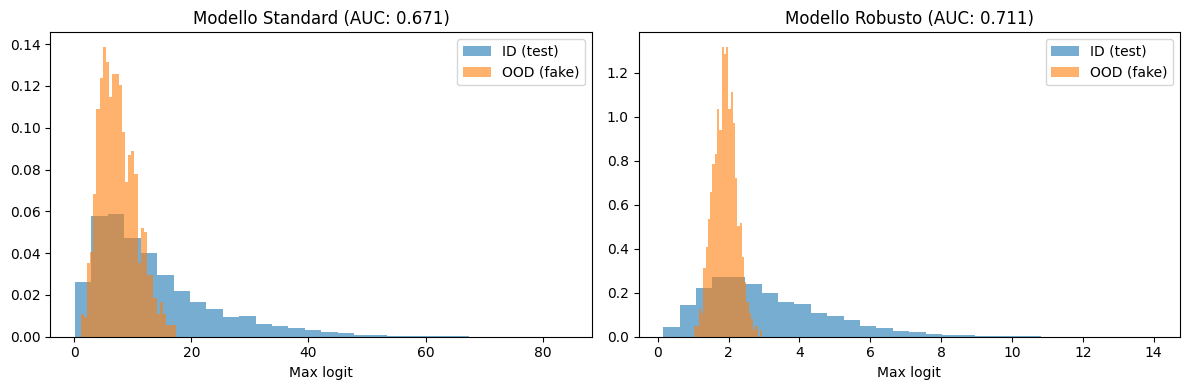

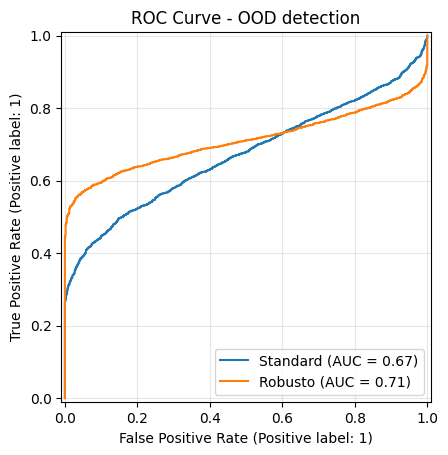

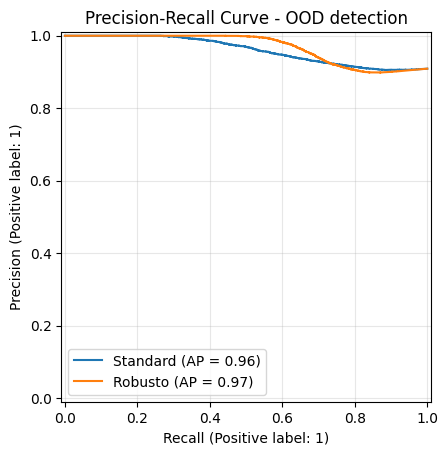

In [44]:
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

# Istogrammi a confronto
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(standard_id_scores.cpu(), alpha=0.6, bins=30, density=True, label='ID (test)')
plt.hist(standard_ood_scores.cpu(), alpha=0.6, bins=30, density=True, label='OOD (fake)')
plt.title(f'Modello Standard (AUC: {auc_standard:.3f})')
plt.xlabel('Max logit')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(robust_id_scores.cpu(), alpha=0.6, bins=30, density=True, label='ID (test)')
plt.hist(robust_ood_scores.cpu(), alpha=0.6, bins=30, density=True, label='OOD (fake)')
plt.title(f'Modello Robusto (AUC: {auc_robust:.3f})')
plt.xlabel('Max logit')
plt.legend()

plt.tight_layout()
plt.show()

# ROC e PR a confronto
RocCurveDisplay.from_predictions(labels, standard_predictions, name='Standard')
RocCurveDisplay.from_predictions(labels, robust_predictions, name='Robusto', ax=plt.gca())
plt.title("ROC Curve - OOD detection")
plt.grid(True, alpha=0.3)
plt.show()

PrecisionRecallDisplay.from_predictions(labels, standard_predictions, name='Standard')
PrecisionRecallDisplay.from_predictions(labels, robust_predictions, name='Robusto', ax=plt.gca())
plt.title("Precision-Recall Curve - OOD detection")
plt.grid(True, alpha=0.3)
plt.show()


## Risultati - Adversarial Training: Robustezza vs OOD Detection

**Robustezza agli attacchi.** Il modello robusto mantiene un'accuratezza superiore al modello standard su tutti i livelli di epsilon testati, con un piccolo costo di accuratezza sui dati puliti (epsilon=0).

**OOD detection.** L'adversarial training non compromette la capacita' di rilevare campioni OOD: gli AUC-ROC dei due modelli restano vicini, e le curve ROC/PR mostrano prestazioni comparabili. Guardando gli istogrammi, il modello robusto tende a produrre score piu' "compressi" (meno overconfident) sia su ID che su OOD, ma la separazione tra le due distribuzioni resta simile a quella del modello standard.

**Conclusione.** L'adversarial training raggiunge l'obiettivo di migliorare la robustezza ad attacchi FGSM senza penalizzare in modo significativo ne' l'accuratezza pulita ne' la capacita' di OOD detection: e' un buon compromesso tra sicurezza e prestazioni.

---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.

### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.

### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.


## Exercise 3.3: Targeted adversarial attacks

In [45]:
# FGSM targeted: genera un esempio avversario che il modello classifica come
# una classe specifica (desired_class), invece di limitarsi a confonderlo.

def create_targeted_attack(model_to_attack, input_image, desired_class, attack_strength, criterion):
    attacked_image = input_image.clone().detach().requires_grad_(True)
    target_tensor = torch.tensor([desired_class]).to(device)

    model_output = model_to_attack(attacked_image)
    attack_loss = criterion(model_output, target_tensor)

    model_to_attack.zero_grad()
    attack_loss.backward()

    # sottraggo il gradiente per MINIMIZZARE la loss verso la classe target
    adversarial_image = attacked_image - attack_strength * attacked_image.grad.sign()
    adversarial_image = torch.clamp(adversarial_image, -1, 1)

    return adversarial_image.detach()


Targeted attack verso la classe: 'ship', epsilon=0.030


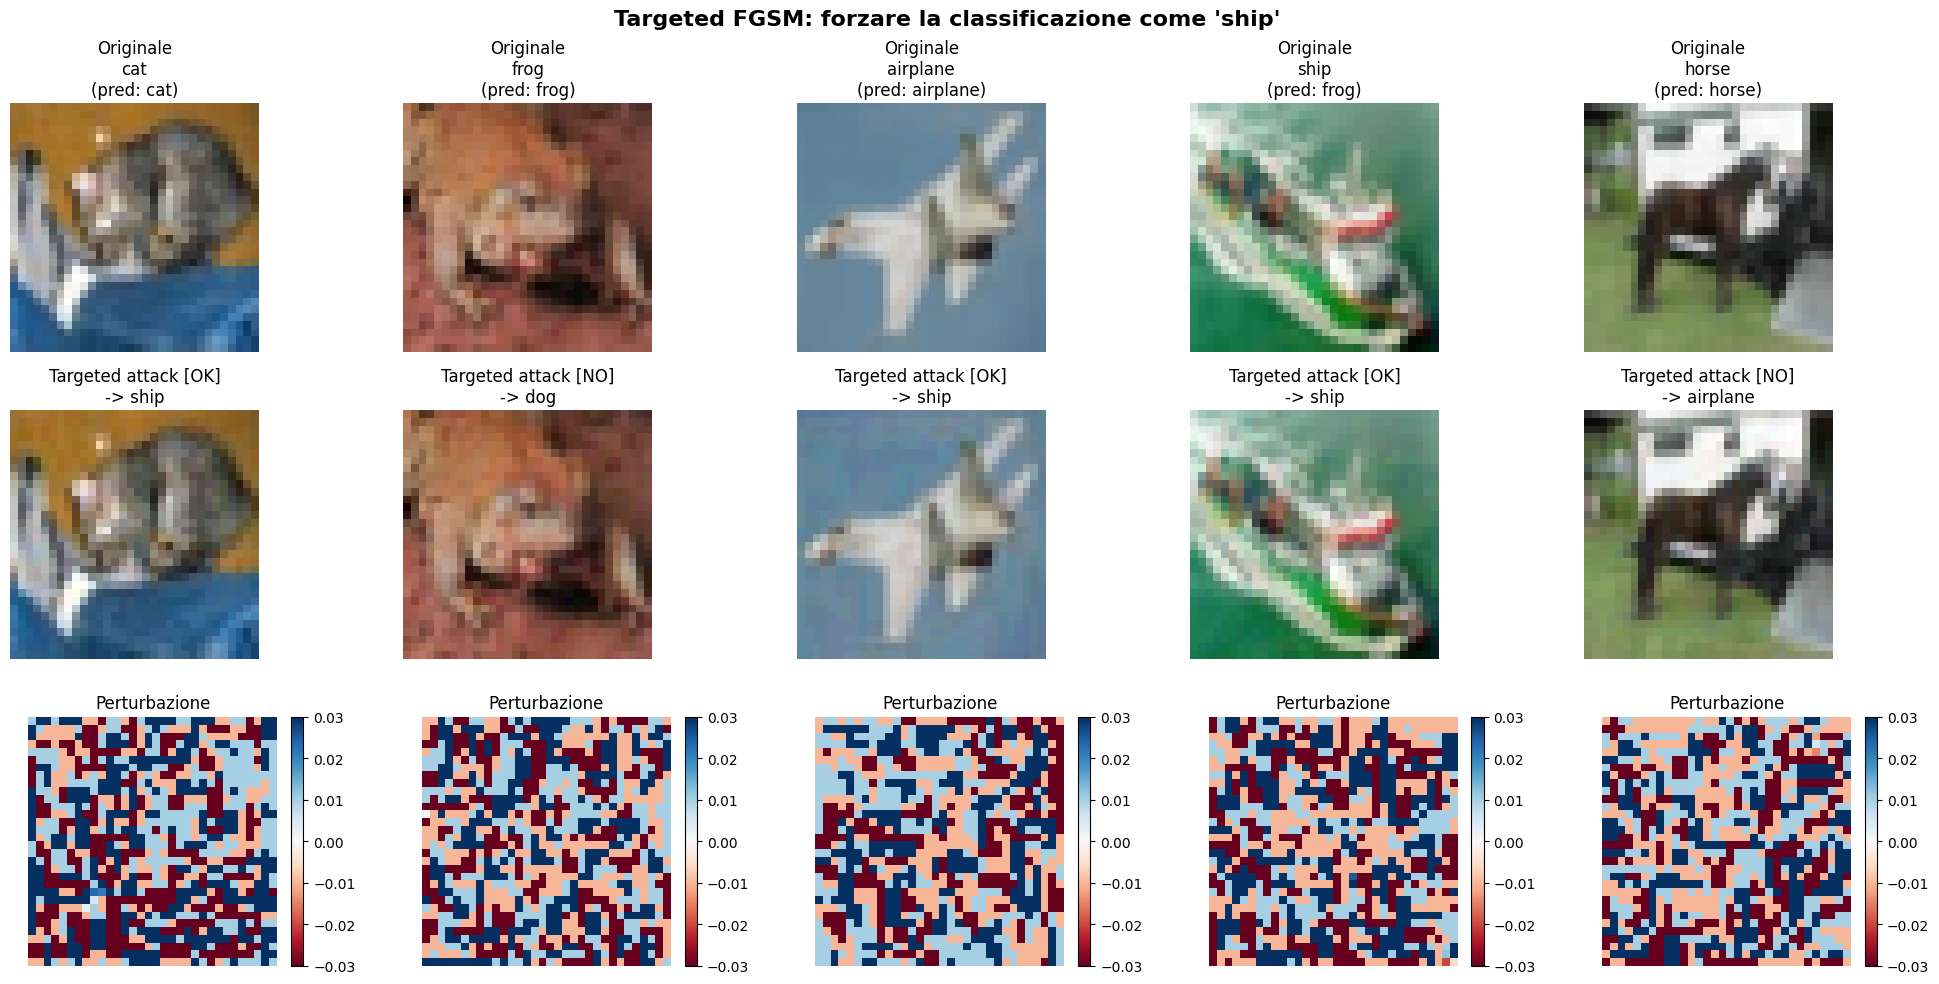

In [46]:
# Test visuale su alcuni esempi: originale, immagine attaccata, perturbazione.

selected_samples = [0, 5, 10, 15, 20]
target_attack_class = class_dict["ship"]
attack_epsilon = 0.03

print(f"Targeted attack verso la classe: '{testset.classes[target_attack_class]}', epsilon={attack_epsilon:.3f}")

model.eval()
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(3, len(selected_samples), figsize=(20, 10))

for idx, sample_idx in enumerate(selected_samples):
    original_img, true_label = testset[sample_idx]
    input_batch = original_img.unsqueeze(0).to(device)

    with torch.no_grad():
        original_pred = model(input_batch).argmax(dim=1).item()

    adversarial_batch = create_targeted_attack(model, input_batch, target_attack_class,
                                                attack_epsilon, criterion)

    with torch.no_grad():
        attacked_pred = model(adversarial_batch).argmax(dim=1).item()

    perturbation = adversarial_batch - input_batch

    axes[0, idx].imshow(inv(input_batch[0]).permute(1, 2, 0).detach().cpu())
    axes[0, idx].set_title(f"Originale\n{testset.classes[true_label]}\n(pred: {testset.classes[original_pred]})")
    axes[0, idx].axis("off")

    success = "OK" if attacked_pred == target_attack_class else "NO"
    axes[1, idx].imshow(inv(adversarial_batch[0]).permute(1, 2, 0).detach().cpu())
    axes[1, idx].set_title(f"Targeted attack [{success}]\n-> {testset.classes[attacked_pred]}")
    axes[1, idx].axis("off")

    # Mappa a singolo canale (media sui 3 canali, segno mantenuto), scala adattiva
    # per ogni immagine: i valori della perturbazione sono troppo piccoli per essere
    # letti come RGB diretto (apparirebbero quasi tutti neri).
    perturbation_map = perturbation[0].detach().cpu().mean(0)
    pert_vmax = perturbation_map.abs().max().item()
    im = axes[2, idx].imshow(perturbation_map, cmap='RdBu', vmin=-pert_vmax, vmax=pert_vmax)
    axes[2, idx].set_title("Perturbazione")
    axes[2, idx].axis("off")
    fig.colorbar(im, ax=axes[2, idx], fraction=0.046, pad=0.04)

plt.suptitle(f"Targeted FGSM: forzare la classificazione come '{testset.classes[target_attack_class]}'",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [47]:
# Success rate dell'attacco targeted su diverse classi target.

def measure_targeted_attack_success(model_to_attack, data_loader, target_class_id, epsilon_value):
    model_to_attack.eval()
    successful_attacks = 0
    total_attempts = 0

    for batch_data, batch_labels in data_loader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        valid_mask = batch_labels != target_class_id
        filtered_data = batch_data[valid_mask]
        if filtered_data.shape[0] == 0:
            continue

        filtered_data = filtered_data.clone().detach().requires_grad_(True)
        target_labels = torch.full((filtered_data.shape[0],), target_class_id,
                                    dtype=torch.long, device=device)

        model_outputs = model_to_attack(filtered_data)
        attack_loss = criterion(model_outputs, target_labels)

        model_to_attack.zero_grad()
        attack_loss.backward()

        attacked_data = filtered_data - epsilon_value * filtered_data.grad.sign()
        attacked_data = torch.clamp(attacked_data, -1, 1)

        with torch.no_grad():
            attacked_predictions = model_to_attack(attacked_data).argmax(dim=1)
            successful_attacks += (attacked_predictions == target_class_id).sum().item()
            total_attempts += filtered_data.shape[0]

    return successful_attacks / total_attempts if total_attempts > 0 else 0

test_targets = ["airplane", "automobile", "deer", "frog", "ship"]
epsilon_test = 0.025

print(f"Success rate targeted attack (epsilon={epsilon_test:.3f})")
print(f"{'Target':<15}{'Success rate':<15}")
print("-"*30)

success_rates = {}
for target_name in test_targets:
    target_id = class_dict[target_name]
    rate = measure_targeted_attack_success(model, testloader, target_id, epsilon_test)
    success_rates[target_name] = rate
    print(f"{target_name:<15}{rate:<15.2%}")


Success rate targeted attack (epsilon=0.025)
Target         Success rate   
------------------------------
airplane       16.90%         
automobile     12.58%         
deer           26.70%         
frog           19.80%         
ship           13.23%         


Epsilon   Targeted (ship)   Untargeted     
---------------------------------------------
0.010     6.58%             53.68%         
0.020     11.29%            69.12%         
0.025     13.23%            73.97%         
0.030     15.23%            77.72%         
0.040     18.19%            82.36%         
0.050     20.40%            84.94%         


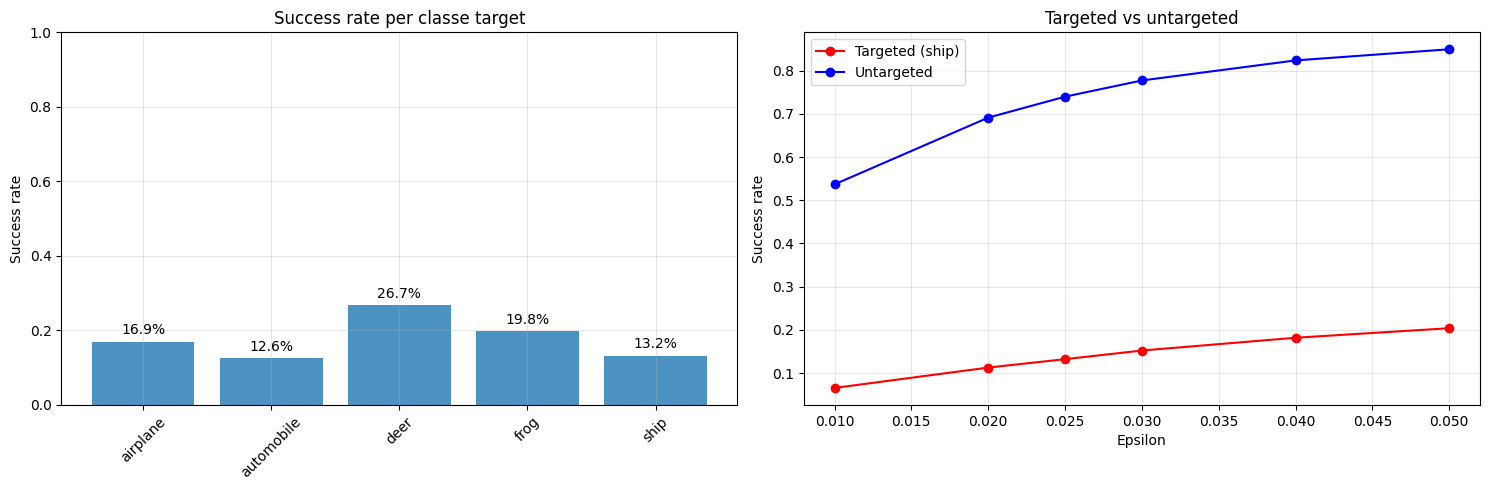

In [48]:
# Confronto targeted vs untargeted su un range di epsilon.

def measure_untargeted_attack_success(model_to_attack, data_loader, epsilon_value):
    model_to_attack.eval()
    successful_attacks = 0
    total_samples = 0

    for batch_data, batch_labels in data_loader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
        batch_data = batch_data.clone().detach().requires_grad_(True)

        model_outputs = model_to_attack(batch_data)
        attack_loss = criterion(model_outputs, batch_labels)

        model_to_attack.zero_grad()
        attack_loss.backward()

        attacked_data = batch_data + epsilon_value * batch_data.grad.sign()
        attacked_data = torch.clamp(attacked_data, -1, 1)

        with torch.no_grad():
            attacked_predictions = model_to_attack(attacked_data).argmax(dim=1)
            successful_attacks += (attacked_predictions != batch_labels).sum().item()
            total_samples += batch_labels.shape[0]

    return successful_attacks / total_samples

epsilon_range = [0.01, 0.02, 0.025, 0.03, 0.04, 0.05]
ship_target_id = class_dict["ship"]

targeted_rates = [measure_targeted_attack_success(model, testloader, ship_target_id, eps) for eps in epsilon_range]
untargeted_rates = [measure_untargeted_attack_success(model, testloader, eps) for eps in epsilon_range]

print(f"{'Epsilon':<10}{'Targeted (ship)':<18}{'Untargeted':<15}")
print("-"*45)
for eps, t_rate, u_rate in zip(epsilon_range, targeted_rates, untargeted_rates):
    print(f"{eps:<10.3f}{t_rate:<18.2%}{u_rate:<15.2%}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
classes_list = list(success_rates.keys())
rates_list = list(success_rates.values())
bars = plt.bar(classes_list, rates_list, alpha=0.8)
plt.title("Success rate per classe target")
plt.ylabel("Success rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
for bar, rate in zip(bars, rates_list):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{rate:.1%}', ha='center')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epsilon_range, targeted_rates, 'ro-', label='Targeted (ship)')
plt.plot(epsilon_range, untargeted_rates, 'bo-', label='Untargeted')
plt.title("Targeted vs untargeted")
plt.xlabel("Epsilon")
plt.ylabel("Success rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Conclusione Esercizio 3.3

Gli attacchi targeted risultano sistematicamente piu' difficili degli attacchi untargeted a parita' di epsilon: forzare il modello verso una classe specifica richiede un budget di perturbazione maggiore rispetto al semplice obiettivo di confonderlo. Il success rate varia inoltre parecchio da classe a classe, segno che alcune rappresentazioni imparate dal modello sono piu' facili da imitare di altre. Le perturbazioni restano comunque piccole e poco visibili anche quando l'attacco ha successo, confermando la natura "silenziosa" degli attacchi adversariali.